<a href="https://colab.research.google.com/github/AncaraniJuanDiego/AnlisisSeriesTemporales/blob/main/Series_SeattleClimate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

El siguiente Data-Set (weather_dataset_2025.csv), contiene registros diarios de multiples variables meteorologicas en diversas ciudades durante todo el año 2025.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
#Analisis descriptivo y descomposición

df = pd.read_excel('seattle-weather.xlsx')
df

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain
...,...,...,...,...,...,...
1456,2015-12-27,8.6,4.4,1.7,2.9,rain
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun


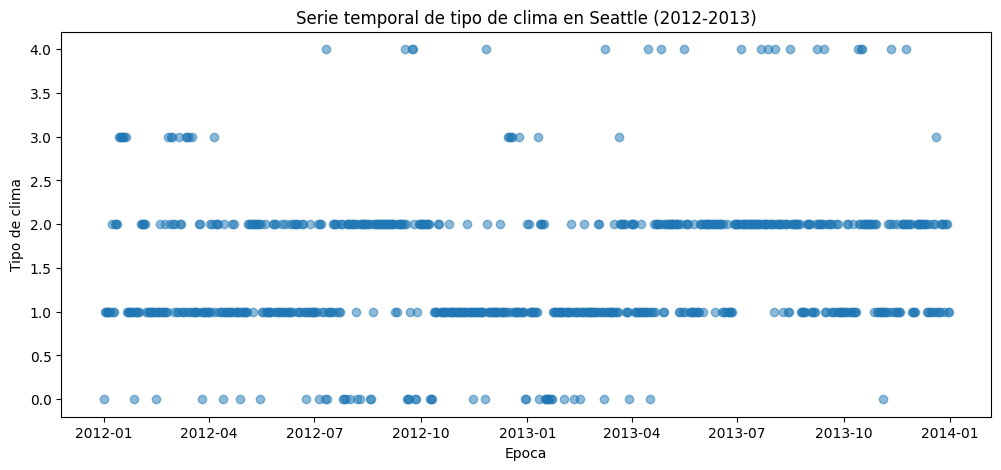

,count
weather,
rain,349
sun,291
drizzle,46
snow,24
fog,21


In [ ]:
#Convertir tipo de variables 'cualititativas' a 'cuantitativas'
weather_numeric_map = {
    'drizzle': 0,
    'rain': 1,
    'sun': 2,
    'snow': 3,
    'fog': 4
}

df['Weather'] = df['weather'].map(weather_numeric_map)

df_years_2012_2013 = df[(df['date'].dt.year == 2012) | (df['date'].dt.year == 2013)]
df_years_2012_2013.set_index('date', inplace= True)


weather_serie = df_years_2012_2013['Weather']
weather_serie.value_counts()

plt.figure(figsize=(12,5))
plt.scatter(df_years_2012_2013.index, weather_serie,
            alpha=0.5)
plt.title('Serie temporal de tipo de clima en Seattle (2012-2013)')
plt.xlabel('Epoca')
plt.ylabel('Tipo de clima')
plt.show()

#Conteo de cada tipo de clima

df_years_2012_2013['weather'].value_counts()

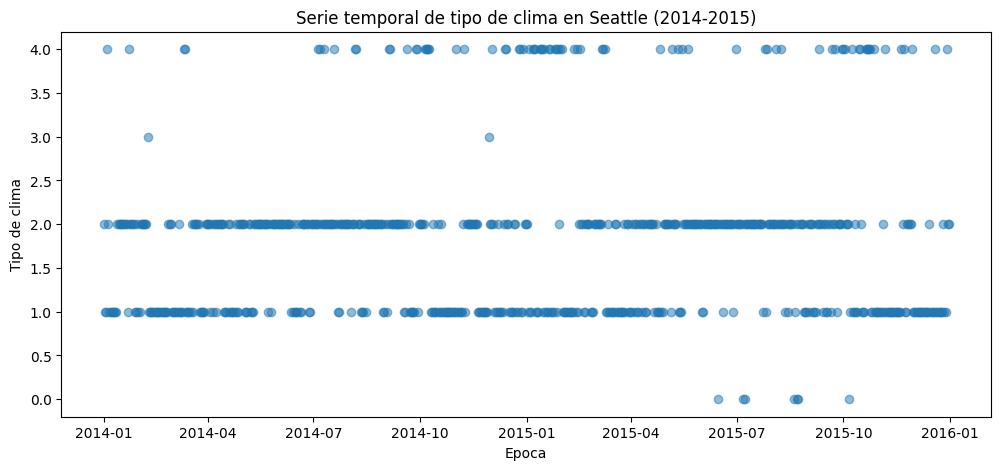

,count
weather,
sun,349
rain,292
fog,80
drizzle,7
snow,2


In [ ]:
df_years_2014_2015 = df[(df['date'].dt.year == 2014) | (df['date'].dt.year == 2015)]
df_years_2014_2015.set_index('date', inplace = True)

weather_serie = df_years_2014_2015['Weather']
weather_serie.value_counts()

plt.figure(figsize=(12,5))
plt.scatter(df_years_2014_2015.index, weather_serie,
            alpha=0.5)
plt.title('Serie temporal de tipo de clima en Seattle (2014-2015)')
plt.xlabel('Epoca')
plt.ylabel('Tipo de clima')
plt.show()

#Conteo de cada tipo de clima.

df_years_2014_2015['weather'].value_counts()


Ahora vamos a observar los comportantes climaticos.

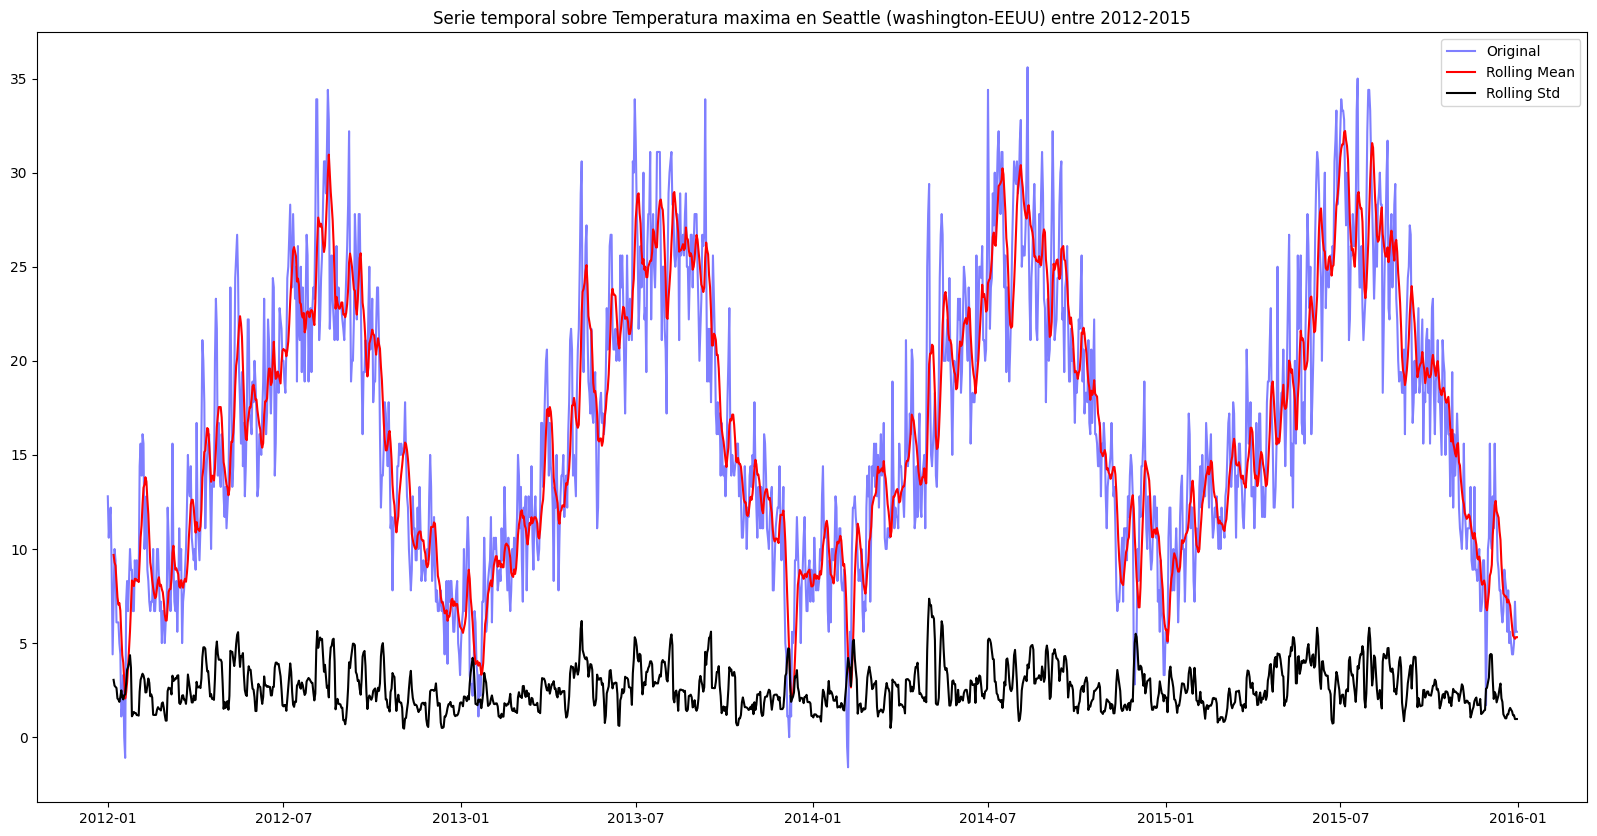

,temp_max
count,1461.000000
mean,16.439083
std,7.349758
min,-1.600000
25%,10.600000
50%,15.600000
75%,22.200000
max,35.600000


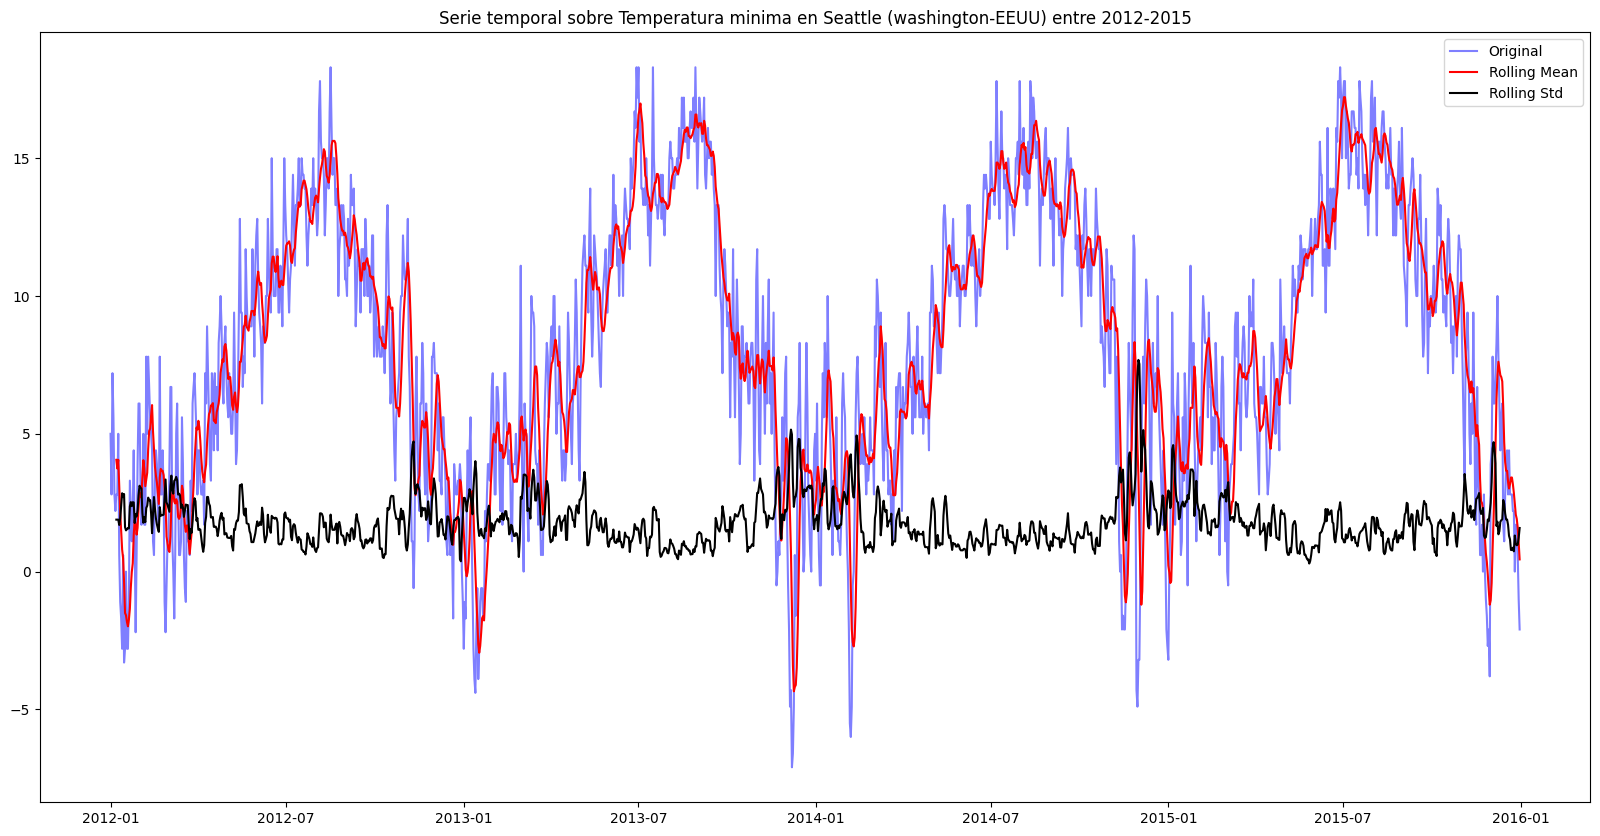

,temp_min
count,1461.000000
mean,8.234771
std,5.023004
min,-7.100000
25%,4.400000
50%,8.300000
75%,12.200000
max,18.300000


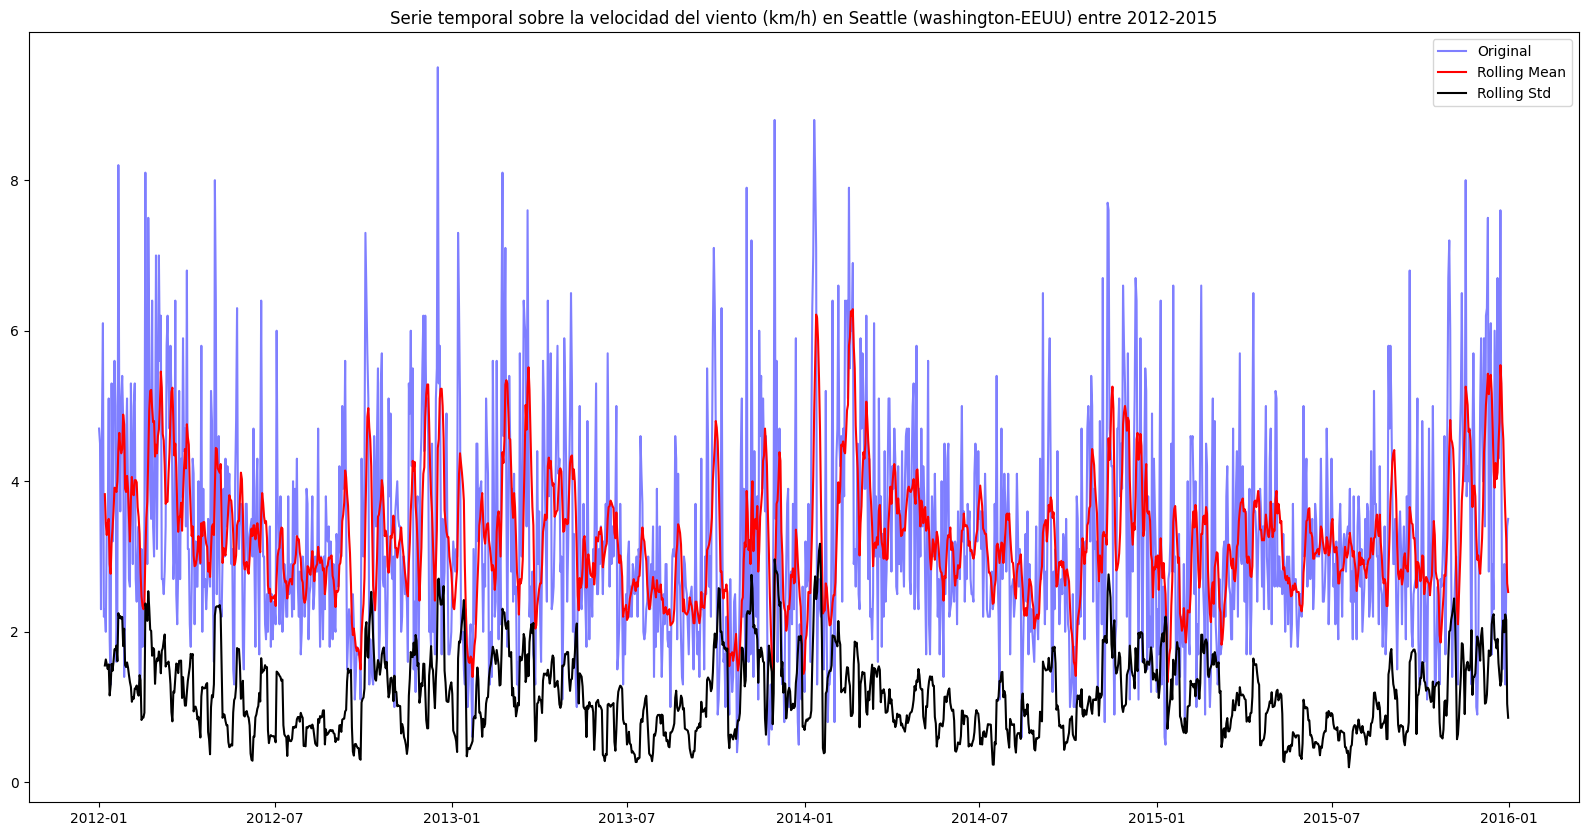

,wind
count,1461.000000
mean,3.241136
std,1.437825
min,0.400000
25%,2.200000
50%,3.000000
75%,4.000000
max,9.500000


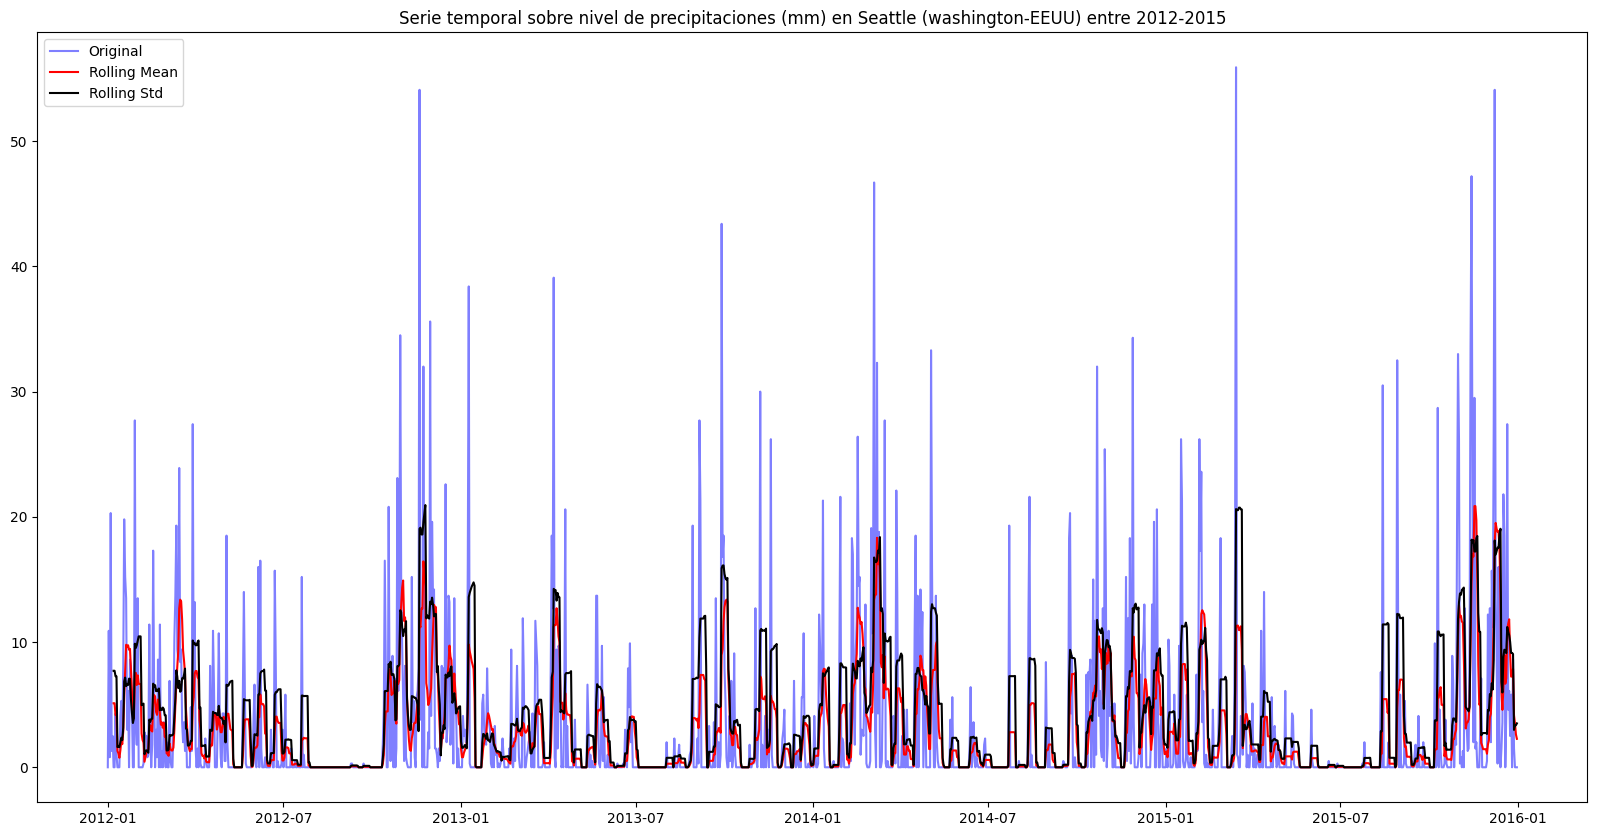

,precipitation
count,1461.000000
mean,3.029432
std,6.680194
min,0.000000
25%,0.000000
50%,0.000000
75%,2.800000
max,55.900000


In [ ]:
#distribucion de Temperatura maxima durante 2012-2015.

df_years_2012_2015 = df[(df['date'].dt.year == 2012) | (df['date'].dt.year == 2013) |
                    (df['date'].dt.year == 2014) | (df['date'].dt.year == 2015)]
df_years_2012_2015.set_index('date', inplace = True)
maxtemperature_years_2012_2015 = df_years_2012_2015['temp_max']

#Calculo de media y desvio estandar para representarlas en el grafico.
rolmean = maxtemperature_years_2012_2015.rolling(window= 7).mean()
rolstd = maxtemperature_years_2012_2015.rolling(window = 7).std()


plt.figure(figsize=(20,10))
plt.plot(maxtemperature_years_2012_2015, color= 'blue', label= 'Original', alpha = 0.5)
plt.plot(rolmean, color = 'red', label = 'Rolling Mean')
plt.plot(rolstd, color = 'black', label = 'Rolling Std')
plt.legend(loc = 'best')
plt.title('Serie temporal sobre Temperatura maxima en Seattle (washington-EEUU) entre 2012-2015')
plt.show()

display(maxtemperature_years_2012_2015.describe())


#Distribución de la temperatura minima en seattle durante 2012-2015.

df_years_2012_2015 = df[(df['date'].dt.year == 2012) | (df['date'].dt.year == 2013) |
                        (df['date'].dt.year == 2014) | (df['date'].dt.year == 2015)]
df_years_2012_2015.set_index('date', inplace = True)
mintemperature_years_2012_2015 = df_years_2012_2015['temp_min']
rolemean = mintemperature_years_2012_2015.rolling(window= 7).mean()
rolstd = mintemperature_years_2012_2015.rolling(window = 7).std()

plt.figure(figsize=(20,10))
plt.plot(mintemperature_years_2012_2015, color = 'blue', label = 'Original', alpha = 0.5)
plt.plot(rolemean, color = 'red', label = 'Rolling Mean')
plt.plot(rolstd, color = 'black', label = 'Rolling Std')
plt.legend(loc = 'best')
plt.title('Serie temporal sobre Temperatura minima en Seattle (washington-EEUU) entre 2012-2015')
plt.show()

display(mintemperature_years_2012_2015.describe())


#Distribución de la velocidad del viento (km/h) en seattle durante 2012-2015.

df_years_2012_2015 = df[(df['date'].dt.year == 2012) | (df['date'].dt.year == 2013) |
                        (df['date'].dt.year == 2014) | (df['date'].dt.year == 2015)]
df_years_2012_2015.set_index('date', inplace = True)
WindSpeed_years_2012_2015 = df_years_2012_2015['wind']
rolemean = WindSpeed_years_2012_2015.rolling(window= 7).mean()
rolstd = WindSpeed_years_2012_2015.rolling(window = 7).std()

plt.figure(figsize=(20,10))
plt.plot(WindSpeed_years_2012_2015, color = 'blue', label = 'Original', alpha = 0.5)
plt.plot(rolemean, color = 'red', label = 'Rolling Mean')
plt.plot(rolstd, color = 'black', label = 'Rolling Std')
plt.legend(loc = 'best')
plt.title('Serie temporal sobre la velocidad del viento (km/h) en Seattle (washington-EEUU) entre 2012-2015')
plt.show()

display(WindSpeed_years_2012_2015.describe())


#Distribución sobre nivel de precipitacion(mm) en seattle durante 2012-2015.


df_years_2012_2015 = df[(df['date'].dt.year == 2012) | (df['date'].dt.year == 2013) |
                        (df['date'].dt.year == 2014) | (df['date'].dt.year == 2015)]
df_years_2012_2015.set_index('date', inplace = True)
Precipitation_years_2012_2015 = df_years_2012_2015['precipitation']
rolemean = Precipitation_years_2012_2015.rolling(window= 7).mean()
rolstd = Precipitation_years_2012_2015.rolling(window = 7).std()

plt.figure(figsize=(20,10))
plt.plot(Precipitation_years_2012_2015, color = 'blue', label = 'Original', alpha = 0.5)
plt.plot(rolemean, color = 'red', label = 'Rolling Mean')
plt.plot(rolstd, color = 'black', label = 'Rolling Std')
plt.legend(loc = 'best')
plt.title('Serie temporal sobre nivel de precipitaciones (mm) en Seattle (washington-EEUU) entre 2012-2015')
plt.show()

display(Precipitation_years_2012_2015.describe())

**Precipitaciones en mm:**

       (<4 mm) : lluvia debil.

       (>4 mm | <15 mm) : lluvia moderada.

       (>15 mm | <60 mm) : lluvia intensa.

       (>60): lluvia torrencial.

Verificar si las series son estacionarias chequeando el p_value..

 valor < 0.05 (la serie es estacionaria).--> no hay suficiente evidencia para afirmar tu hipotesis.

 valor > 0.05 (la serie NO es estacionaria)--> hay suficiente evidencia para afirmar tu hipotesis.


H0) 'La serie no es estacionaria'

H1) 'La serie es estacionaria '


In [ ]:
#Verificar estacionariedad de la serie 'maxtemperature_years_2012_2015'
def verific_est_tempMx(maxtemperature_years_2012_2015, temp_max):
  result = adfuller(maxtemperature_years_2012_2015)
  print(f'Prueba de estacionariedad para {temp_max}: ')
  resultado = adfuller(maxtemperature_years_2012_2015.dropna())

  p_value= resultado[1]
  estadistico_adf = resultado[0]

  print(f'Estadistico ADF: {estadistico_adf}')
  print(f'p-value: {p_value}')

  if p_value <= 0.05:
    print('La serie (temp_max) es estacionaria (rechazamos H0)')
  else:
    print('La serie (temp_max) no es estacionaria (aceptamos H0)')

verific_est_tempMx(maxtemperature_years_2012_2015, 'temp_max')
print('.................................................')
#Verificar estacionariedad de la serie 'mintemperature_years_2012_2015'
def verific_est_tempMn(mintemperature_years_2012_2015, temp_min):
  result = adfuller(mintemperature_years_2012_2015)
  print(f'Prueba de estacionariedad para {temp_min}: ')
  resultado = adfuller(mintemperature_years_2012_2015.dropna())

  p_value= resultado[1]
  estadistico_adf = resultado[0]

  print(f'Estadistico ADF: {estadistico_adf}')
  print(f'p-value: {p_value}')

  if p_value <= 0.05:
    print('La serie (temp_min) es estacionaria (rechazamos H0)')
  else:
    print('La serie (temp_min) no es estacionaria (aceptamos H0)')

verific_est_tempMn(mintemperature_years_2012_2015, 'temp_min')
print('.................................................')

#Verificar estacionariedad de la seria 'WindSpeed_years_2012_2015'

def verific_est_WindSpeed(WindSpeed_years_2012_2015, wind):
  result = adfuller(WindSpeed_years_2012_2015)
  print(f'Prueba de estacionariedad para {wind}: ')
  resultado = adfuller(WindSpeed_years_2012_2015.dropna())

  p_value= resultado[1]
  estadistico_adf = resultado[0]

  print(f'Estadistico ADF: {estadistico_adf}')
  print(f'p-value: {p_value}')

  if p_value <= 0.05:
    print('La serie (wind_speed) es estacionaria (rechazamos H0)')
  else:
    print('La serie (wind_speed) no es estacionaria (aceptamos H0)')

verific_est_WindSpeed(WindSpeed_years_2012_2015, 'wind_speed')
print('.................................................')

def verific_est_precipitation(Precipitation_years_2012_2015, precipitation):
  result = adfuller(Precipitation_years_2012_2015)
  print(f'Prueba de estacionariedad para {precipitation}: ')
  resultado = adfuller(Precipitation_years_2012_2015.dropna())

  p_value= resultado[1]
  estadistico_adf = resultado[0]

  print(f'Estadistico ADF: {estadistico_adf}')
  print(f'p-value: {p_value}')

  if p_value <= 0.05:
    print('La serie (precipitation) es estacionaria (rechazamos H0)')
  else:
    print('La serie (precipitation) no es estacionaria (aceptamos H0)')

verific_est_precipitation(Precipitation_years_2012_2015, 'precipitation')


Prueba de estacionariedad para temp_max: 
Estadistico ADF: -2.429204969464816
p-value: 0.1336625918843134
La serie (temp_max) no es estacionaria (aceptamos H0)
.................................................
Prueba de estacionariedad para temp_min: 
Estadistico ADF: -2.6056195336348176
p-value: 0.09184137745869753
La serie (temp_min) no es estacionaria (aceptamos H0)
.................................................
Prueba de estacionariedad para wind_speed: 
Estadistico ADF: -24.50737190120076
p-value: 0.0
La serie (wind_speed) es estacionaria (rechazamos H0)
.................................................
Prueba de estacionariedad para precipitation: 
Estadistico ADF: -16.797530555019133
p-value: 1.2277972200476751e-29
La serie (precipitation) es estacionaria (rechazamos H0)


Diferenciación: Diferencia entre un valor y el valor anterior (para entender patrones bruscos).

(Y) - (Y-1)

In [ ]:
#Diferenciacion sobre temperatura minima

dif_tempMax = maxtemperature_years_2012_2015.diff().dropna()
display(dif_tempMax[(dif_tempMax > 9) | (dif_tempMax < -8)])

dif_tempMin = mintemperature_years_2012_2015.diff().dropna()
display(dif_tempMin[(dif_tempMin > 6) | (dif_tempMin < -6)])

dif_WindSpeed = WindSpeed_years_2012_2015.diff().dropna()
display(dif_WindSpeed[(dif_WindSpeed > 2) | (dif_WindSpeed < -2)])

dif_Precipitation = Precipitation_years_2012_2015.diff().dropna()
display(dif_Precipitation[(dif_Precipitation > 3) | (dif_Precipitation < -3)])

,temp_max
date,
2012-06-22,-10.0
2012-08-18,-11.1
2013-05-07,-10.0
2013-06-28,9.5
2013-07-17,-8.9
2013-09-12,-8.3
2014-05-02,-11.1
2014-08-12,-8.4
2014-09-16,-8.4


,temp_min
date,
2012-02-07,6.1
2012-02-21,6.1
2013-03-02,-6.1
2013-03-05,6.1
2013-12-02,-6.1
2013-12-13,6.1
2014-03-03,6.1
2014-11-28,-8.4
2014-11-29,-7.6


,wind
date,
2012-01-03,-2.2
2012-01-04,2.4
2012-01-06,-3.9
2012-01-12,-3.2
2012-01-14,4.0
...,...
2015-12-20,2.6
2015-12-21,-2.4
2015-12-23,2.6


,precipitation
date,
2012-01-02,10.9
2012-01-03,-10.1
2012-01-04,19.5
2012-01-05,-19.0
2012-01-09,4.3
...,...
2015-12-24,-3.6
2015-12-25,3.3
2015-12-26,-5.8


Correlacion y autocorrelacion

**¿Que tan correlacionadas estan las diferentes variables?**

**Temperatura**: suele tener una ACF muy alto y de caida lenta. Esto indica presencia de 'persistencia'. Es decir, que si hoy hace calor, mañana tambien lo haga.

**Viento**: Suele tener un ACF que cae a cero de inmediato. Esto indica que el viento es mas parecido al ruido blanco (una media concentrada en 0), no tiene memoria.

**Precipitaciones**: La media siempre se mantiene en un mismo intervalo, exceptuando los dias donde hubo lluvias fuertes. Esto agregando que hay dias que las variables son 0, entonces la lluvia no suele cambiar respecto a una estación del año.



In [ ]:
# Calculate and print the correlation matrix for numerical columns
print(df[['precipitation','temp_max','temp_min','wind']].corr())

               precipitation  temp_max  temp_min      wind
precipitation       1.000000 -0.228555 -0.072684  0.328045
temp_max           -0.228555  1.000000  0.875687 -0.164857
temp_min           -0.072684  0.875687  1.000000 -0.074185
wind                0.328045 -0.164857 -0.074185  1.000000


In [ ]:

from statsmodels.graphics.tsaplots import plot_acf

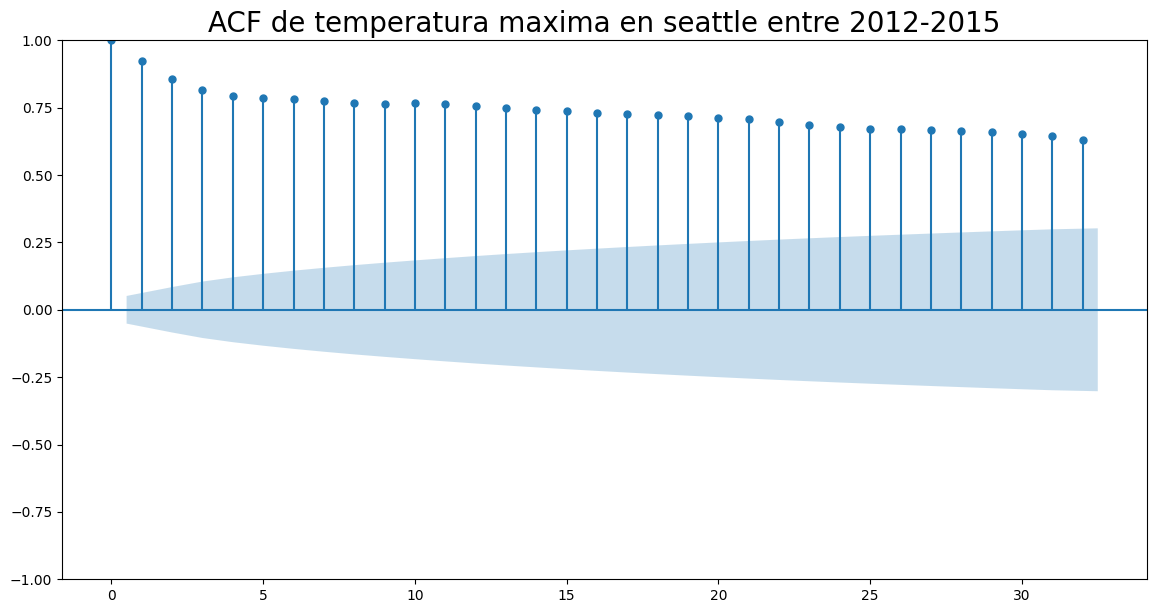

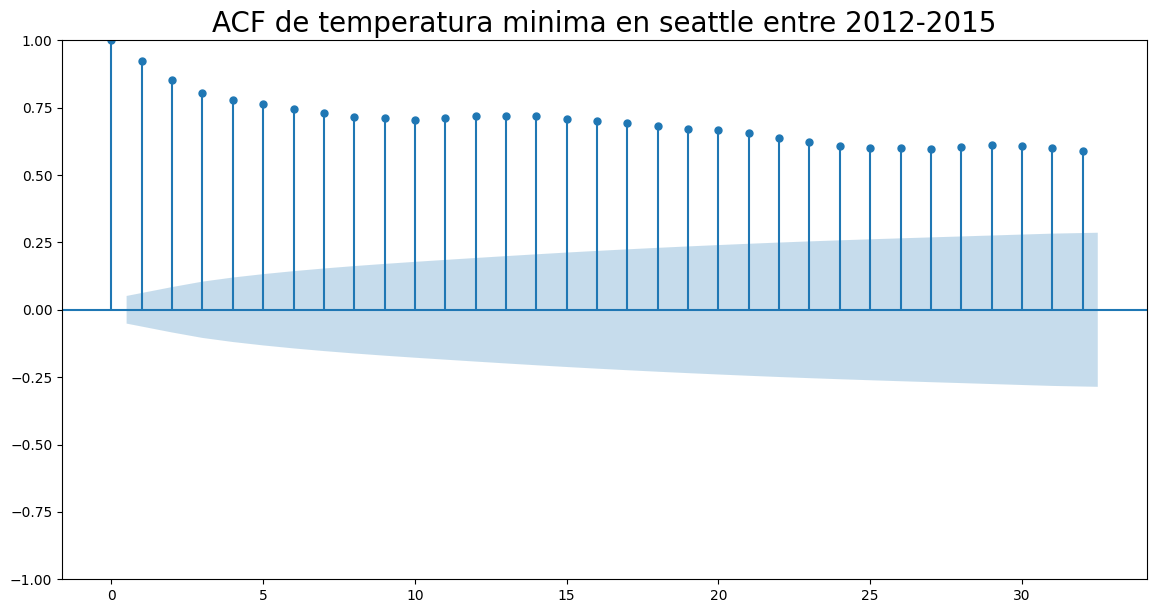

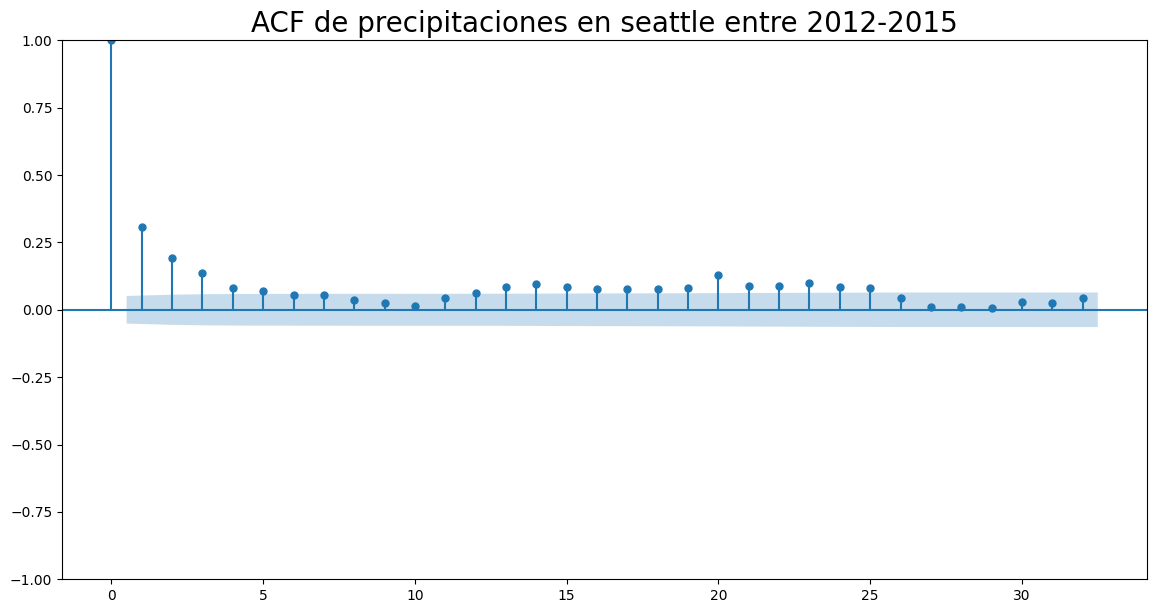

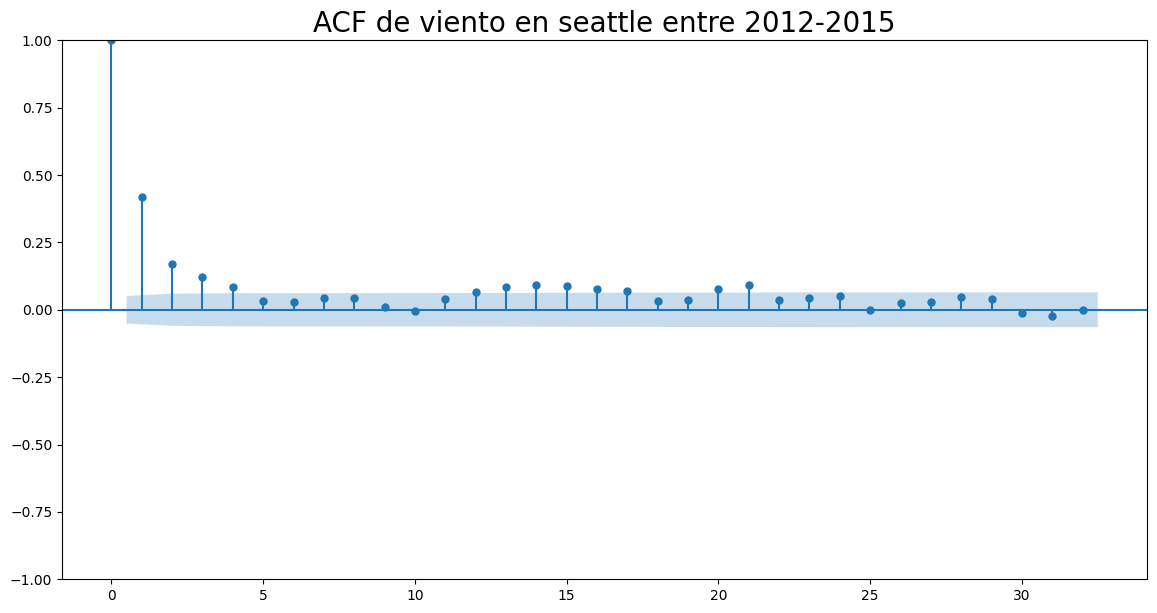

In [ ]:

#grafico de correlación ACF (Ruido entre dias intermedios)

fig, ax = plt.subplots(figsize=(14,7))
plot_acf(df_years_2012_2015['temp_max'], ax=ax)
plt.title('ACF de temperatura maxima en seattle entre 2012-2015', fontsize= 20)
plt.show()

fig, ax = plt.subplots(figsize=(14,7))
plot_acf(df_years_2012_2015['temp_min'], ax=ax)
plt.title('ACF de temperatura minima en seattle entre 2012-2015', fontsize= 20)
plt.show()

fig, ax = plt.subplots(figsize=(14,7))
plot_acf(df_years_2012_2015['precipitation'], ax=ax)
plt.title('ACF de precipitaciones en seattle entre 2012-2015', fontsize=20)
plt.show()

fig, ax = plt.subplots(figsize=(14,7))
plot_acf(df_years_2012_2015['wind'], ax=ax)
plt.title('ACF de viento en seattle entre 2012-2015', fontsize=20)
plt.show()

**Graficos de correlograma en base a la herramienta FACP (ruido entre variables mensuales)...**

--Caclularemos la variable de un dia determinado con la de meses pasados..

--Recordar que estamos estudiando el comportamiento climatico de seattle durante 3 años seguidos (2012-15 o en  36 meses). Por lo tanto la variable (X) estara conformada por 36 lags.

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

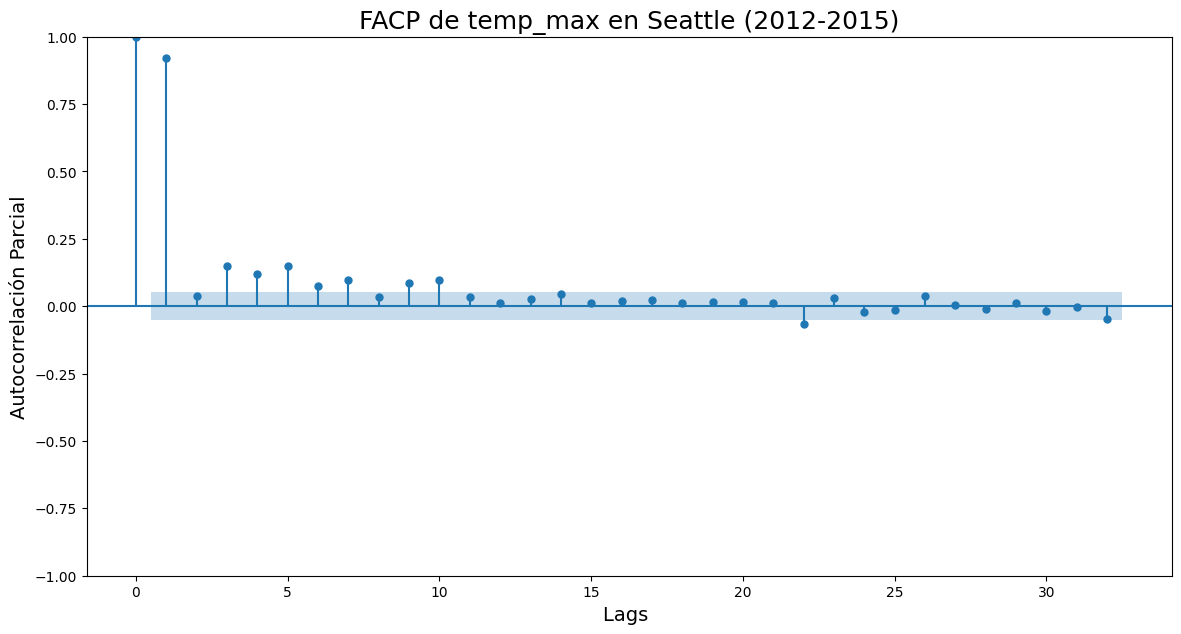

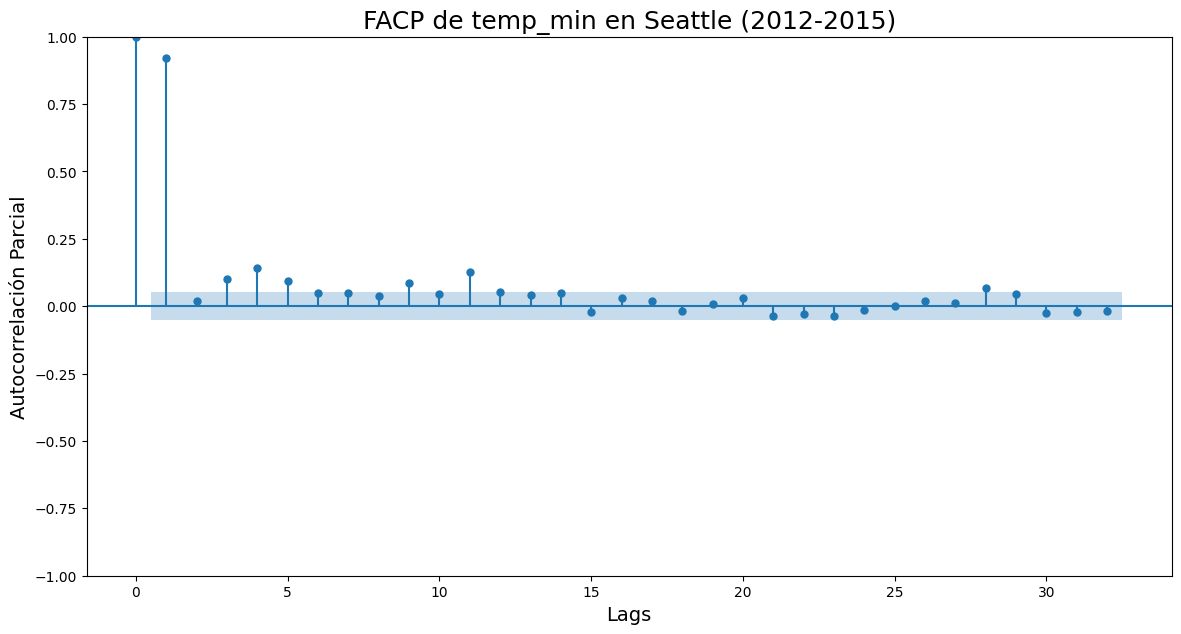

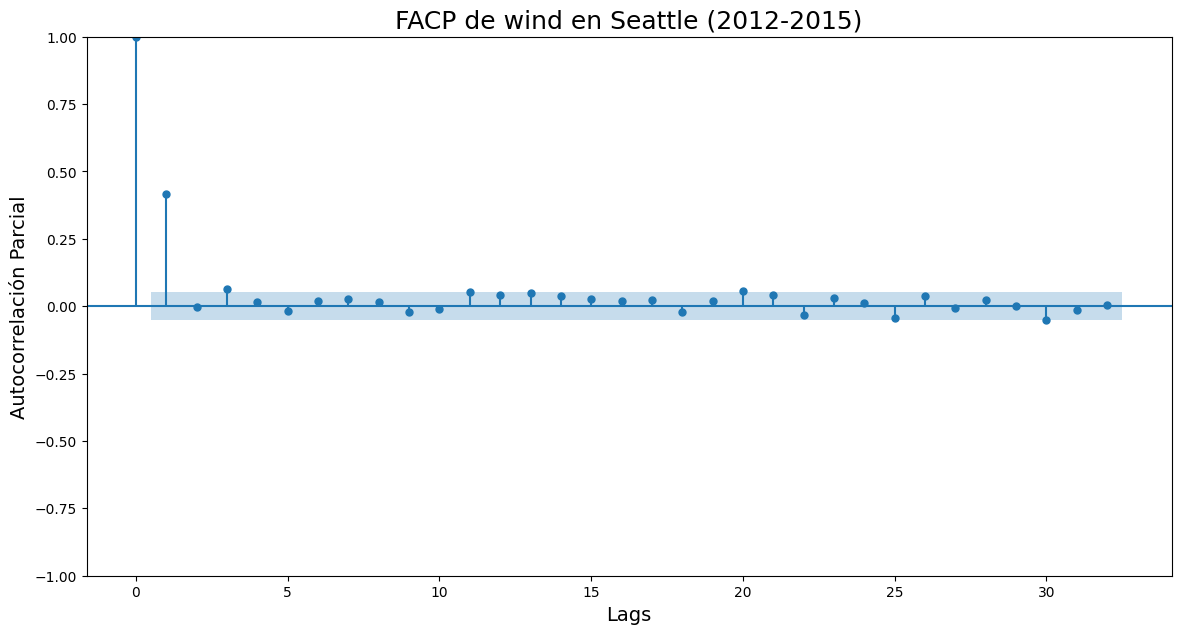

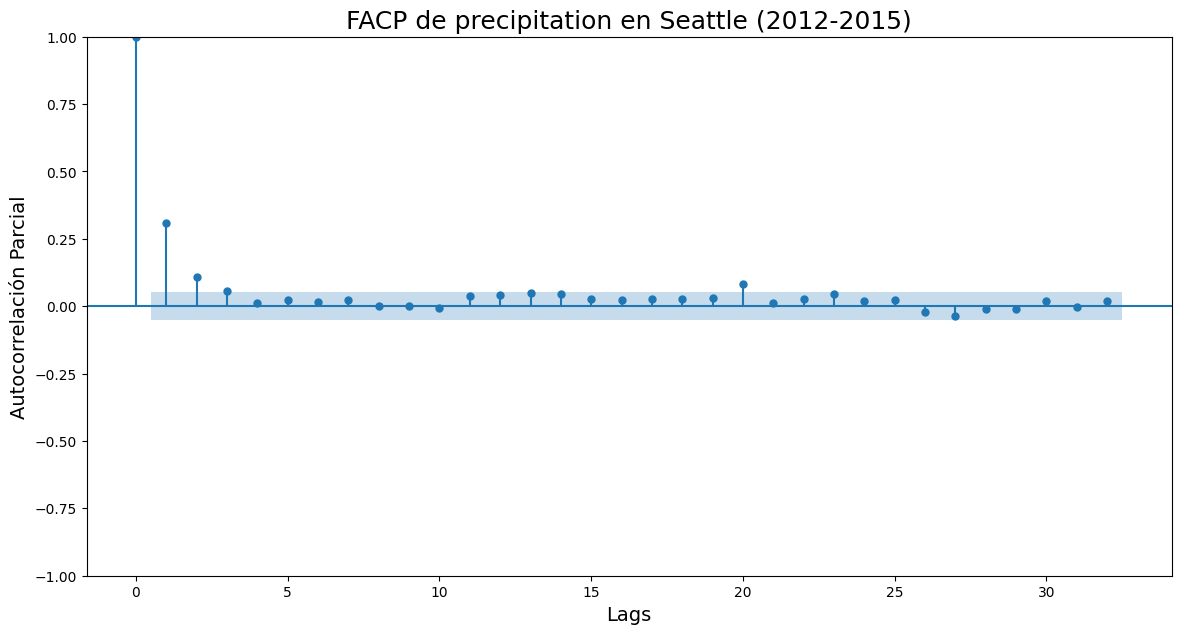

In [ ]:
#Verificar FACP → ¿La temperatura maxima de hoy, se correlaciona con la del mes pasado?..


fig, ax = plt.subplots(figsize=(14, 7))

    # Graficamos el FACP (PACF) pasándole el eje 'ax'
    # 'lags=30' es un buen estándar para ver el comportamiento del mes
plot_pacf(df_years_2012_2015['temp_max'], ax=ax)
ax.set_title(f'FACP de {'temp_max'} en Seattle (2012-2015)', fontsize=18)
ax.set_xlabel('Lags ', fontsize=14)
ax.set_ylabel('Autocorrelación Parcial', fontsize=14)

plt.show()

#en algunos lags, la correlacion es negativa. Es decir, que la correlacion de ese mes

#¿La temperatura minima de hoy, se correlaciona con la del mes pasado?..
fig, ax = plt.subplots(figsize=(14, 7))

    # Graficamos el FACP (PACF) pasándole el eje 'ax'
    # 'lags=30' es un buen estándar para ver el comportamiento del mes
plot_pacf(df_years_2012_2015['temp_min'], ax=ax)
ax.set_title(f'FACP de {'temp_min'} en Seattle (2012-2015)', fontsize=18)
ax.set_xlabel('Lags', fontsize=14)
ax.set_ylabel('Autocorrelación Parcial', fontsize=14)

plt.show()

#¿La velocidad del viento en km/h se hoy, se correlaciona con la del mes pasado?..
fig, ax = plt.subplots(figsize=(14, 7))

    # Graficamos el FACP (PACF) pasándole el eje 'ax'
    # 'lags=30' es un buen estándar para ver el comportamiento del mes
plot_pacf(df_years_2012_2015['wind'], ax=ax)
ax.set_title(f'FACP de {'wind'} en Seattle (2012-2015)', fontsize=18)
ax.set_xlabel('Lags', fontsize=14)
ax.set_ylabel('Autocorrelación Parcial', fontsize=14)

plt.show()


#¿el nivel de precipitacion (mm) de hoy, se correlaciona con la del mes pasado?..
fig, ax = plt.subplots(figsize=(14, 7))

    # Graficamos el FACP (PACF) pasándole el eje 'ax'
    # 'lags=30' es un buen estándar para ver el comportamiento del mes
plot_pacf(df_years_2012_2015['precipitation'], ax=ax)
ax.set_title(f'FACP de {'precipitation'} en Seattle (2012-2015)', fontsize=18)
ax.set_xlabel('Lags', fontsize=14)
ax.set_ylabel('Autocorrelación Parcial', fontsize=14)

plt.show()

Calculo de AutoModelado.

In [ ]:
from statsmodels.tsa.ar_model import AutoReg

In [ ]:
df.index = pd.to_datetime(df['date'])
df = df.asfreq('D')

In [ ]:
lags = 5
model = AutoReg(df['temp_max'], lags)
ajusted_model = model.fit()
print(ajusted_model.summary())

                            AutoReg Model Results                             
Dep. Variable:               temp_max   No. Observations:                 1461
Model:                     AutoReg(5)   Log Likelihood               -3533.841
Method:               Conditional MLE   S.D. of innovations              2.741
Date:                Wed, 15 Apr 2026   AIC                           7081.681
Time:                        22:13:32   BIC                           7118.665
Sample:                    01-06-2012   HQIC                          7095.480
                         - 12-31-2015                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.7506      0.185      4.047      0.000       0.387       1.114
temp_max.L1     0.8450      0.026     32.656      0.000       0.794       0.896
temp_max.L2    -0.0878      0.034     -2.579    

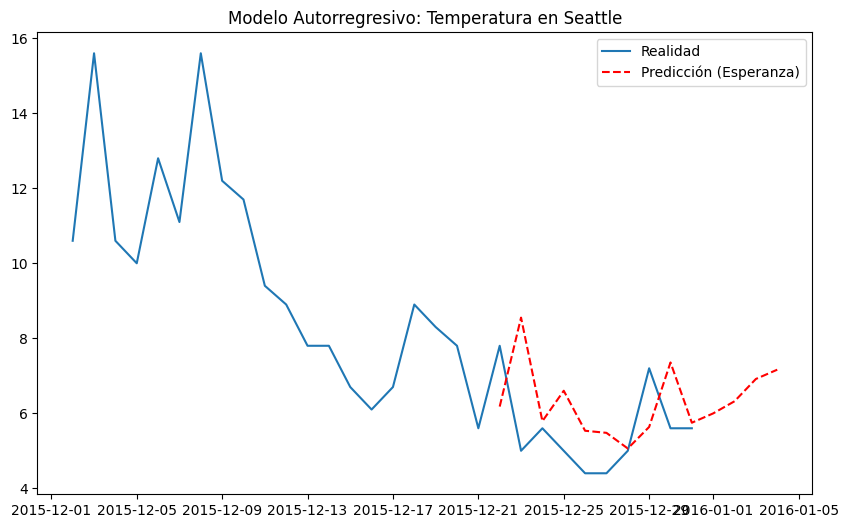

In [ ]:
# Predecir los últimos 10 días y los 3 días siguientes al dataset
predictions = ajusted_model.predict(start= len(df) - 10, end= len(df) + 3)

# Graficar la realidad vs la esperanza del modelo
plt.figure(figsize=(10,6))
plt.plot(df['temp_max'].tail(30), label='Realidad')
plt.plot(predictions, label='Predicción (Esperanza)', color='red', linestyle='--')
plt.legend()
plt.title("Modelo Autorregresivo: Temperatura en Seattle")
plt.show()